# Análisis de absentismo y bienestar laboral - 08/06/2026

## 1. Pregunta de negocio

> ¿Cómo influyen el consumo social de alcohol o tabaco y los antecedentes disciplinarios en los niveles de absentismo?

El análisis busca detectar asociaciones, no demostrar causalidad.

## 2. Dataset limpio utilizado y alcance

Usamos el archivo limpio consolidado del `01/06/2026`. Esta parte no repite el
data cleaning; controla la muestra y las variables que entran en el análisis.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import levene, mannwhitneyu, shapiro, ttest_ind

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# Paleta RRHH Green definida por el equipo.
COLOR_VERDE_PRINCIPAL = '#7FB8A4'
COLOR_VERDE_CLARO = '#A8D5C2'
COLOR_VERDE_OSCURO = '#5E9C87'
COLOR_VERDE_MUY_CLARO = '#CFE8DE'
COLOR_GRIS = '#D9D9D9'
COLOR_TEXTO = '#2B2B2B'
PALETA_GRUPOS = [COLOR_GRIS, COLOR_VERDE_OSCURO]

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.labelcolor': COLOR_TEXTO,
    'text.color': COLOR_TEXTO,
    'savefig.facecolor': 'white'
})

DATA_FILE = '../../Data/clean/clean_data_01062026.csv'
df_rrhh = pd.read_csv(DATA_FILE)

### 2.1 Control inicial del dataset

Se revisan tamaño, IDs y horas de absentismo para que el análisis sea trazable.

In [55]:
alcance = pd.DataFrame({
    'métrica': [
        'registros limpios',
        'IDs observados',
        'horas totales de absentismo',
        'registros con ausencia > 0 horas'
    ],
    'valor': [
        len(df_rrhh),
        df_rrhh['ID'].nunique(),
        df_rrhh['Absenteeism_hours'].sum(),
        (df_rrhh['Absenteeism_hours'] > 0).sum()
    ]
})

display(alcance)
display(df_rrhh.head())

,métrica,valor
0,registros limpios,844
1,IDs observados,136
2,horas totales de absentismo,6226
3,registros con ausencia > 0 horas,801


,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,12,14,34,284.031,97,0,1,Secundaria,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,13,18,50,239.409,98,0,1,Secundaria,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,14,16,58,264.604,93,0,1,Secundaria,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,26,9,28,230.290,92,0,1,Secundaria,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,14,16,58,222.196,99,0,1,Secundaria,2,0,0,1,65,172,22,22.0,112,2026-05-25


**Lectura:** el dataset contiene `844` registros correspondientes a
`136` empleados. Como una misma persona puede aparecer en múltiples filas, el número
de registros no puede utilizarse como tamaño de muestra para comparar hábitos o
antecedentes. Las conclusiones se construirán sobre una fila por empleado.

------------

## 3. Variables consideradas y unidad de análisis

La lista se limita a las variables solicitadas por la pregunta de negocio:

- **Primer factor:** `Disciplinary_failure`, antecedente/falta disciplinaria.
- **Hábitos sociales:** `Social_drinker` y `Social_smoker`.
- **Variable de resultado:** horas totales de absentismo por empleado.

Los factores describen al empleado y se repiten en varias filas. Para no tratar registros del mismo ID como observaciones independientes, los contrastes se
realizan a nivel de empleado. 
`Disciplinary_failure` se agrega primero con `max()` para identificar si el ID tuvo al menos una falta disciplinaria.

In [56]:
factores = [
    'Disciplinary_failure',
    'Social_drinker',
    'Social_smoker'
]
variable_resultado = 'horas_totales_absentismo'

df_registros = df_rrhh[
    ['ID', 'Absenteeism_hours', *factores]
].copy()

df_empleados = (
    df_rrhh
    .groupby('ID', as_index=False)
    .agg(
        horas_totales_absentismo=('Absenteeism_hours', 'sum'),
        Disciplinary_failure=('Disciplinary_failure', 'max'),
        Social_drinker=('Social_drinker', 'first'),
        Social_smoker=('Social_smoker', 'first')
    )
)

df_empleados[factores + [variable_resultado]].describe().T

,count,mean,std,min,25%,50%,75%,max
Disciplinary_failure,136.0,0.147059,0.355474,0.0,0.0,0.0,0.0,1.0
Social_drinker,136.0,0.522059,0.501360,0.0,0.0,1.0,1.0,1.0
Social_smoker,136.0,0.102941,0.305005,0.0,0.0,0.0,0.0,1.0
horas_totales_absentismo,136.0,45.779412,112.379561,0.0,2.0,8.0,16.0,596.0


**Lectura:** la agregación por `ID` convierte las horas registradas en
horas totales por empleado y conserva cada factor como una característica binaria.
Esta decisión evita que los empleados con más registros tengan más peso estadístico
solo por aparecer más veces.

### 3.1 Composición de los grupos dentro del absentismo

La elipse exterior representa a los empleados que presentan absentismo. Dentro se
muestran los tres grupos incluidos en la pregunta y sus solapamientos.

La zona exterior al Venn identifica a los empleados con absentismo que no son
fumadores sociales, no son bebedores sociales y no tienen antecedentes
disciplinarios.

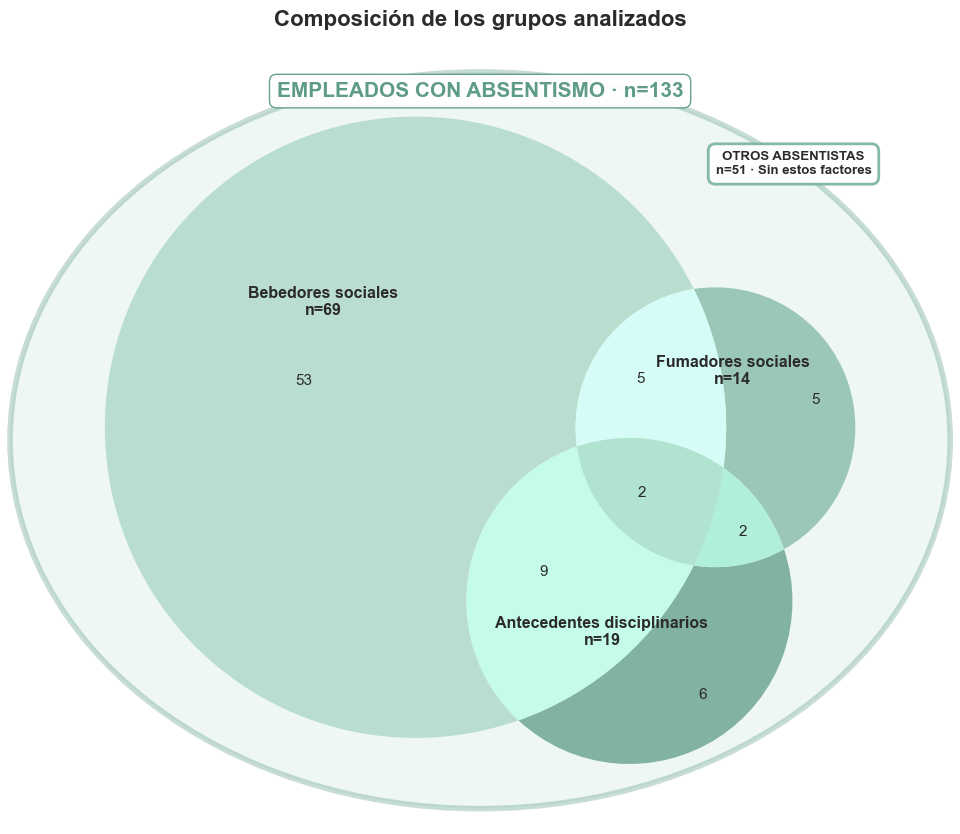

,grupo,empleados
0,Empleados con absentismo,133
1,Dentro de al menos uno de los tres factores,82
2,Otros perfiles con absentismo,51


In [65]:
from matplotlib.patches import Ellipse
from matplotlib_venn import venn3

# Una fila por empleado: hábitos mediante first(), antecedentes mediante max().
grupos_venn = (
    df_rrhh
    .groupby('ID', as_index=False)
    .agg(
        horas_totales_absentismo=('Absenteeism_hours', 'sum'),
        Social_drinker=('Social_drinker', 'first'),
        Social_smoker=('Social_smoker', 'first'),
        Disciplinary_failure=('Disciplinary_failure', 'max')
    )
)

ids_con_absentismo = set(
    grupos_venn.loc[grupos_venn['horas_totales_absentismo'] > 0, 'ID']
)
set_bebedores = set(
    grupos_venn.loc[
        (grupos_venn['Social_drinker'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)
set_fumadores = set(
    grupos_venn.loc[
        (grupos_venn['Social_smoker'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)
set_antecedentes = set(
    grupos_venn.loc[
        (grupos_venn['Disciplinary_failure'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)

union_factores = set_bebedores | set_fumadores | set_antecedentes
otros_con_absentismo = ids_con_absentismo - union_factores

fig, ax = plt.subplots(figsize=(12, 8.5))
ax.axis('off')

# El Venn se genera sin etiquetas externas; los nombres se colocan dentro.
venn = venn3(
    [set_bebedores, set_fumadores, set_antecedentes],
    set_labels=('', '', ''),
    set_colors=(
        COLOR_VERDE_CLARO,
        COLOR_VERDE_PRINCIPAL,
        COLOR_VERDE_OSCURO
    ),
    alpha=0.75,
    ax=ax
)

# Elipse exterior: universo completo de empleados con absentismo.
elipse_absentismo = Ellipse(
    (0.5, 0.5),
    width=1.08,
    height=0.96,
    transform=ax.transAxes,
    facecolor=COLOR_VERDE_MUY_CLARO,
    edgecolor=COLOR_VERDE_OSCURO,
    linewidth=4,
    alpha=0.34,
    zorder=-10,
    clip_on=False
)
ax.add_patch(elipse_absentismo)

for label in venn.subset_labels:
    if label is not None:
        label.set_fontsize(11)
        label.set_color(COLOR_TEXTO)

# Título del conjunto exterior, claramente separado de los conjuntos internos.
ax.text(
    0.5,
    0.955,
    f'EMPLEADOS CON ABSENTISMO · n={len(ids_con_absentismo)}',
    transform=ax.transAxes,
    fontsize=15,
    fontweight='bold',
    color=COLOR_VERDE_OSCURO,
    ha='center',
    va='center',
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'edgecolor': COLOR_VERDE_OSCURO,
        'alpha': 0.95
    }
)

# Etiquetas dentro de cada conjunto.
ax.text(
    0.32,
    0.68,
    f'Bebedores sociales\nn={len(set_bebedores)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color=COLOR_TEXTO
)
ax.text(
    0.79,
    0.59,
    f'Fumadores sociales\nn={len(set_fumadores)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color=COLOR_TEXTO
)
ax.text(
    0.64,
    0.25,
    f'Antecedentes disciplinarios\nn={len(set_antecedentes)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color=COLOR_TEXTO
)

# La caja de otros perfiles se sitúa en la zona superior derecha libre.
ax.text(
    0.86,
    0.86,
    f'OTROS ABSENTISTAS\nn={len(otros_con_absentismo)} · Sin estos factores',
    transform=ax.transAxes,
    fontsize=9.5,
    fontweight='bold',
    color=COLOR_TEXTO,
    ha='center',
    va='center',
    bbox={
        'boxstyle': 'round,pad=0.55',
        'facecolor': 'white',
        'edgecolor': COLOR_VERDE_PRINCIPAL,
        'linewidth': 2,
        'alpha': 0.96
    }
)

ax.set_title(
    'Composición de los grupos analizados',
    fontsize=16,
    fontweight='bold',
    color=COLOR_TEXTO,
    pad=22
)
plt.tight_layout()
plt.savefig('grafica0_venn_grupos.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'grupo': [
        'Empleados con absentismo',
        'Dentro de al menos uno de los tres factores',
        'Otros perfiles con absentismo'
    ],
    'empleados': [
        len(ids_con_absentismo),
        len(union_factores),
        len(otros_con_absentismo)
    ]
})

Los tres factores de estudio **no** describen el 100% del absentismo. <br>
De los `133` empleados con horas de ausencia, `82` pertenecen
al menos a uno de los tres grupos y `51` quedan fuera de ellos. <br>
Esta zona de “otros perfiles” muestra que también existe absentismo sin consumo social de alcohol o tabaco y sin antecedentes disciplinarios.

## 4. Validación previa de `Disciplinary_failure`

Antes de correr ningún test se comprueba la variable disciplinaria en las dosunidades posibles.<br> 
A nivel de registro, todas las filas con falta disciplinaria tienen cero horas. <br>
A nivel de empleado, `max()` identifica si el ID tuvo al menos una falta y las horas se acumulan sin perder sus otros registros.

In [58]:
validacion_disciplinaria_registros = (
    df_registros
    .groupby('Disciplinary_failure')
    .agg(
        registros=('ID', 'size'),
        empleados=('ID', 'nunique'),
        registros_con_ausencia=(
            'Absenteeism_hours',
            lambda serie: (serie > 0).sum()
        ),
        horas_totales=('Absenteeism_hours', 'sum'),
        media_horas=('Absenteeism_hours', 'mean'),
        mediana_horas=('Absenteeism_hours', 'median'),
        valores_unicos_horas=('Absenteeism_hours', 'nunique')
    )
)

validacion_disciplinaria_empleados = (
    df_empleados
    .groupby('Disciplinary_failure')
    .agg(
        empleados=('ID', 'size'),
        horas_totales=(variable_resultado, 'sum'),
        media_horas=(variable_resultado, 'mean'),
        mediana_horas=(variable_resultado, 'median'),
        valores_unicos_horas=(variable_resultado, 'nunique')
    )
)

display(validacion_disciplinaria_registros)
display(validacion_disciplinaria_empleados)

,registros,empleados,registros_con_ausencia,horas_totales,media_horas,mediana_horas,valores_unicos_horas
Disciplinary_failure,,,,,,,
0,805,136,801,6226,7.734161,3.0,19
1,39,20,0,0,0.000000,0.0,1


,empleados,horas_totales,media_horas,mediana_horas,valores_unicos_horas
Disciplinary_failure,,,,,
0,116,2828,24.37931,4.0,21
1,20,3398,169.90000,111.0,19


**Lectura previa al test:** el contraste por filas no es adecuado porque repite empleados y `Disciplinary_failure = 1` aparece
estructuralmente asociado a filas de cero horas. Por eso el test se ejecuta a nivel de `ID`: cada empleado aparece una vez, se conserva si tuvo una falta y se
comparan sus horas totales de absentismo.

## 5. Estadísticos descriptivos por empleado

Primero se observan tamaño, media, mediana y variabilidad de los grupos `0/1`.
La elección del test se realiza después de esta revisión.

In [59]:
resumen_descriptivo = (
    df_empleados
    .melt(
        id_vars=['ID', variable_resultado],
        value_vars=factores,
        var_name='factor',
        value_name='grupo'
    )
    .groupby(['factor', 'grupo'])
    .agg(
        empleados=('ID', 'size'),
        horas_totales=(variable_resultado, 'sum'),
        media_horas=(variable_resultado, 'mean'),
        mediana_horas=(variable_resultado, 'median'),
        valores_unicos=(variable_resultado, 'nunique')
    )
    .round(2)
)

resumen_descriptivo

empleados  horas_totales  media_horas  \
factor               grupo                                          
Disciplinary_failure 0            116           2828        24.38   
                     1             20           3398       169.90   
Social_drinker       0             65           2459        37.83   
                     1             71           3767        53.06   
Social_smoker        0            122           5835        47.83   
                     1             14            391        27.93   

                            mediana_horas  valores_unicos  
factor               grupo                                 
Disciplinary_failure 0                4.0              21  
                     1              111.0              19  
Social_drinker       0                8.0              20  
                     1                8.0              25  
Social_smoker        0                7.0              31  
                     1               12.0              10

**Lectura descriptiva:**

- `Disciplinary_failure` presenta la mayor diferencia visible: mediana de `111`
  horas entre empleados con antecedentes frente a `4` horas entre quienes no los
  tienen.
- `Social_drinker` presenta la misma mediana en ambos grupos: `8` horas.
- `Social_smoker` presenta una mediana superior entre fumadores (`12` frente a
  `7` horas), pero el grupo contiene solo `14` empleados.

Las medias y medianas cuentan historias diferentes en algunos grupos, lo que indica
asimetría y presencia de valores extremos. Por eso la interpretación no debe basarse
únicamente en la media.

## 6. Selección y aplicación del test

Para cada factor binario se comprueba que existan dos grupos, variabilidad y normalidad aproximada.<br> 
Si algún grupo es pequeño, constante o no normal, se aplica `Mann-Whitney U`. <br>
Solo si ambos grupos son aproximadamente normales se evalúan varianzas para elegir entre `t-test de Student` y `Welch t-test`.
La unidad de análisis es el empleado, por lo que cada ID interviene una sola vez.

In [60]:
def seleccionar_test_binario(
    dataframe,
    factor,
    target='Absenteeism_hours',
    alpha=0.05
):
    datos = dataframe[[factor, target]].dropna()
    grupos = sorted(datos[factor].unique())

    if len(grupos) != 2:
        return {
            'factor': factor,
            'test_usado': 'No aplicable',
            'p_value': np.nan,
            'motivo': 'La variable no tiene exactamente dos grupos.'
        }

    grupo_0 = datos.loc[datos[factor] == grupos[0], target]
    grupo_1 = datos.loc[datos[factor] == grupos[1], target]
    n_0, n_1 = len(grupo_0), len(grupo_1)
    constante_0 = grupo_0.nunique() <= 1
    constante_1 = grupo_1.nunique() <= 1
    shapiro_p_0 = np.nan
    shapiro_p_1 = np.nan
    levene_p = np.nan

    if constante_0 and constante_1:
        test_usado = 'No aplicable'
        estadistico = np.nan
        p_value = np.nan
        motivo = 'Ambos grupos son constantes.'
    elif constante_0 or constante_1 or n_0 < 30 or n_1 < 30:
        test_usado = 'Mann-Whitney U'
        estadistico, p_value = mannwhitneyu(
            grupo_0,
            grupo_1,
            alternative='two-sided'
        )
        motivo = 'Hay un grupo constante o con menos de 30 observaciones.'
    else:
        shapiro_p_0 = shapiro(grupo_0).pvalue
        shapiro_p_1 = shapiro(grupo_1).pvalue
        grupos_normales = shapiro_p_0 >= alpha and shapiro_p_1 >= alpha

        if not grupos_normales:
            test_usado = 'Mann-Whitney U'
            estadistico, p_value = mannwhitneyu(
                grupo_0,
                grupo_1,
                alternative='two-sided'
            )
            motivo = 'No se cumple normalidad aproximada.'
        else:
            levene_p = levene(grupo_0, grupo_1).pvalue
            varianzas_iguales = levene_p >= alpha
            test_usado = (
                't-test de Student'
                if varianzas_iguales
                else 'Welch t-test'
            )
            estadistico, p_value = ttest_ind(
                grupo_0,
                grupo_1,
                equal_var=varianzas_iguales
            )
            motivo = (
                'Normalidad aproximada y varianzas similares.'
                if varianzas_iguales
                else 'Normalidad aproximada y varianzas diferentes.'
            )

    return {
        'factor': factor,
        'n_grupo_0': n_0,
        'n_grupo_1': n_1,
        'media_grupo_0': grupo_0.mean(),
        'media_grupo_1': grupo_1.mean(),
        'mediana_grupo_0': grupo_0.median(),
        'mediana_grupo_1': grupo_1.median(),
        'shapiro_p_grupo_0': shapiro_p_0,
        'shapiro_p_grupo_1': shapiro_p_1,
        'levene_p': levene_p,
        'test_usado': test_usado,
        'estadistico': estadistico,
        'p_value': p_value,
        'significativo_005': p_value < alpha if pd.notna(p_value) else False,
        'motivo': motivo
    }


resultados_tests = pd.DataFrame([
    seleccionar_test_binario(df_empleados, factor, variable_resultado)
    for factor in factores
])

resultados_tests

,factor,n_grupo_0,n_grupo_1,media_grupo_0,media_grupo_1,mediana_grupo_0,mediana_grupo_1,shapiro_p_grupo_0,shapiro_p_grupo_1,levene_p,test_usado,estadistico,p_value,significativo_005,motivo
0,Disciplinary_failure,116,20,24.379310,169.900000,4.0,111.0,NaN,NaN,NaN,Mann-Whitney U,292.5,6.696142e-08,True,Hay un grupo constante o con menos de 30 obser...
1,Social_drinker,65,71,37.830769,53.056338,8.0,8.0,1.174009e-14,1.356977e-14,NaN,Mann-Whitney U,2212.0,6.748824e-01,False,No se cumple normalidad aproximada.
2,Social_smoker,122,14,47.827869,27.928571,7.0,12.0,NaN,NaN,NaN,Mann-Whitney U,563.5,3.531183e-02,True,Hay un grupo constante o con menos de 30 obser...


In [61]:
# Tamaño del efecto basado en rangos: diferencia en la probabilidad
# de que un empleado del grupo 1 presente más horas que uno del grupo 0.
def efecto_rank_biserial(dataframe, factor, target):
    grupo_0 = dataframe.loc[dataframe[factor] == 0, target].dropna()
    grupo_1 = dataframe.loc[dataframe[factor] == 1, target].dropna()
    u_grupo_0, _ = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
    return 1 - (2 * u_grupo_0) / (len(grupo_0) * len(grupo_1))


resultados_tests['efecto_rank_biserial'] = [
    efecto_rank_biserial(df_empleados, factor, variable_resultado)
    for factor in resultados_tests['factor']
]

resultados_tests[['factor', 'test_usado', 'p_value', 'efecto_rank_biserial']]

,factor,test_usado,p_value,efecto_rank_biserial
0,Disciplinary_failure,Mann-Whitney U,6.696142e-08,0.747845
1,Social_drinker,Mann-Whitney U,6.748824e-01,0.041387
2,Social_smoker,Mann-Whitney U,3.531183e-02,0.340164


**Lectura del test:** se utiliza `Mann-Whitney U` en los tres factores
porque las distribuciones no son normales o uno de los grupos es pequeño. El
p-valor indica si existe evidencia de diferencias, mientras que el tamaño del
efecto ayuda a valorar su intensidad y dirección.

- Un efecto cercano a `0` indica distribuciones similares.
- Un efecto positivo indica que el grupo `1` tiende a presentar más horas.
- El resultado debe interpretarse junto con el tamaño de cada grupo y el contexto
  de la variable.

## 7. Visualización comparativa

Se priorizan mediana y dispersión porque las distribuciones por empleado no son normales.

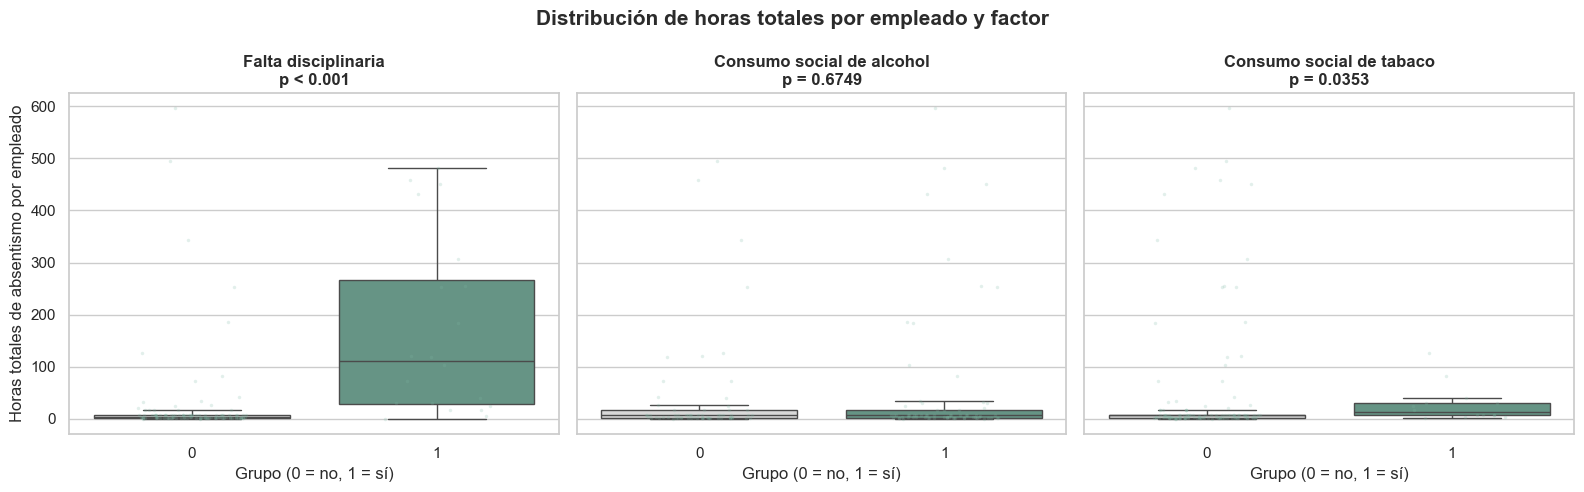

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
nombres = {
    'Disciplinary_failure': 'Falta disciplinaria',
    'Social_drinker': 'Consumo social de alcohol',
    'Social_smoker': 'Consumo social de tabaco'
}

for axis, factor in zip(axes, factores):
    sns.boxplot(
        data=df_empleados,
        x=factor,
        y=variable_resultado,
        hue=factor,
        palette=PALETA_GRUPOS,
        legend=False,
        showfliers=False,
        ax=axis
    )
    sns.stripplot(
        data=df_empleados,
        x=factor,
        y=variable_resultado,
        color=COLOR_VERDE_PRINCIPAL,
        alpha=0.22,
        size=2.5,
        jitter=0.22,
        ax=axis
    )
    p_value = resultados_tests.loc[
        resultados_tests['factor'] == factor,
        'p_value'
    ].iloc[0]
    etiqueta_p = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.4f}'
    axis.set_title(f"{nombres[factor]}\n{etiqueta_p}", fontweight='bold')
    axis.set_xlabel('Grupo (0 = no, 1 = sí)')
    axis.set_ylabel('Horas totales de absentismo por empleado')

fig.suptitle(
    'Distribución de horas totales por empleado y factor',
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('grafica1_boxplot_factores.png', dpi=150, bbox_inches='tight')
plt.show()

**Lectura del boxplot:** la falta disciplinaria muestra una separación
visual clara entre grupos. En alcohol, las cajas y medianas son muy similares. En
tabaco, la mediana del grupo fumador es superior, pero el reducido tamaño del grupo
y los valores extremos impiden convertir esta diferencia en una conclusión fuerte.

El boxplot es útil para mostrar mediana y dispersión, pero los valores extremos
comprimen visualmente los grupos de alcohol y tabaco. Por eso se añade una curva
acumulada para comparar toda la distribución.

## 8. Resultados de los contrastes

La tabla resume el test elegido después de validar los supuestos. El p-valor se interpreta junto con medias, medianas y tamaños de grupo.

In [63]:
resumen_tests = resultados_tests[[
    'factor',
    'n_grupo_0',
    'n_grupo_1',
    'media_grupo_0',
    'media_grupo_1',
    'mediana_grupo_0',
    'mediana_grupo_1',
    'test_usado',
    'p_value',
    'significativo_005',
    'motivo'
]].copy()

columnas_redondear = [
    'media_grupo_0',
    'media_grupo_1',
    'mediana_grupo_0',
    'mediana_grupo_1',
    'p_value'
]
resumen_tests[columnas_redondear] = resumen_tests[
    columnas_redondear
].round(4)

resumen_tests

,factor,n_grupo_0,n_grupo_1,media_grupo_0,media_grupo_1,mediana_grupo_0,mediana_grupo_1,test_usado,p_value,significativo_005,motivo
0,Disciplinary_failure,116,20,24.3793,169.9000,4.0,111.0,Mann-Whitney U,0.0000,True,Hay un grupo constante o con menos de 30 obser...
1,Social_drinker,65,71,37.8308,53.0563,8.0,8.0,Mann-Whitney U,0.6749,False,No se cumple normalidad aproximada.
2,Social_smoker,122,14,47.8279,27.9286,7.0,12.0,Mann-Whitney U,0.0353,True,Hay un grupo constante o con menos de 30 obser...


### 8.1 Resumen visual para la presentación

Este gráfico resume la mediana de cada grupo, el tamaño muestral y la significación.
Es más directo para una diapositiva, mientras que el boxplot y la ECDF conservan el
detalle estadístico en el notebook.

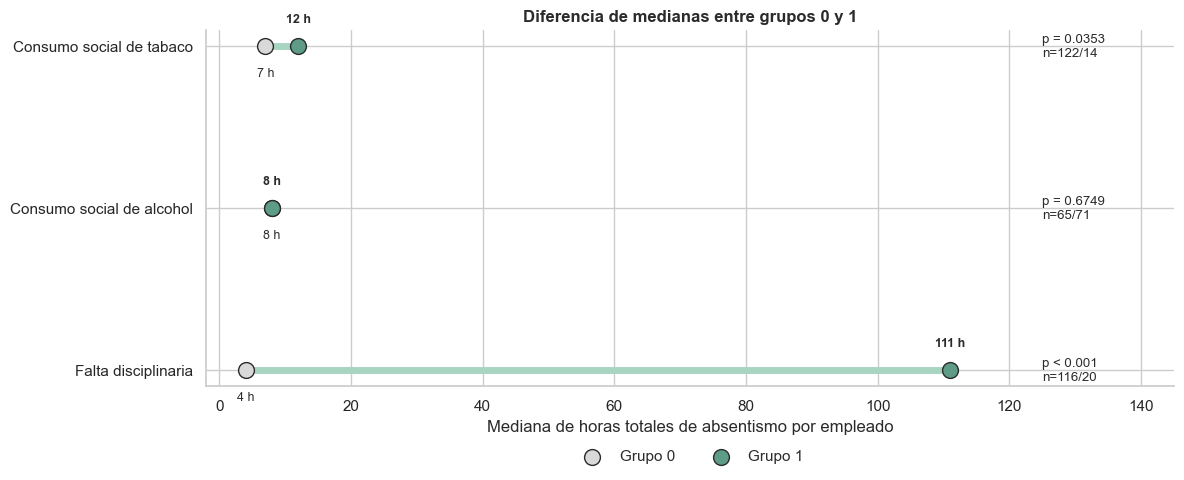

In [64]:
resumen_visual = resultados_tests.copy()
resumen_visual['factor_nombre'] = resumen_visual['factor'].map(nombres)

fig, ax = plt.subplots(figsize=(12, 5.5))
posiciones = np.arange(len(resumen_visual))

for posicion, fila in resumen_visual.iterrows():
    mediana_0 = fila['mediana_grupo_0']
    mediana_1 = fila['mediana_grupo_1']
    ax.plot(
        [mediana_0, mediana_1],
        [posicion, posicion],
        color=COLOR_VERDE_CLARO,
        linewidth=5,
        solid_capstyle='round'
    )
    ax.scatter(
        mediana_0,
        posicion,
        s=130,
        color=COLOR_GRIS,
        edgecolor=COLOR_TEXTO,
        label='Grupo 0' if posicion == 0 else None,
        zorder=3
    )
    ax.scatter(
        mediana_1,
        posicion,
        s=130,
        color=COLOR_VERDE_OSCURO,
        edgecolor=COLOR_TEXTO,
        label='Grupo 1' if posicion == 0 else None,
        zorder=3
    )
    ax.text(
        mediana_0,
        posicion - 0.13,
        f'{mediana_0:.0f} h',
        ha='center',
        va='top',
        fontsize=9
    )
    ax.text(
        mediana_1,
        posicion + 0.13,
        f'{mediana_1:.0f} h',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
    p_texto = 'p < 0.001' if fila['p_value'] < 0.001 else f"p = {fila['p_value']:.4f}"
    ax.text(
        125,
        posicion,
        f"{p_texto}\nn={int(fila['n_grupo_0'])}/{int(fila['n_grupo_1'])}",
        va='center',
        fontsize=9.5
    )

ax.set_xlim(-2, 145)
ax.set_yticks(posiciones)
ax.set_yticklabels(resumen_visual['factor_nombre'])
ax.set_xlabel('Mediana de horas totales de absentismo por empleado')
ax.set_title('Diferencia de medianas entre grupos 0 y 1', fontweight='bold')
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.14),
    ncol=2
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('grafica3_resumen_medianas.png', dpi=150, bbox_inches='tight')
plt.show()

**Lectura ejecutiva:** el gráfico permite separar tres mensajes:

1. **Alcohol:** las medianas son iguales y no existe evidencia estadística de
   diferencias.
2. **Tabaco:** existe una señal estadística, pero el grupo es pequeño y la
   diferencia debe validarse con una muestra mayor.
3. **Antecedentes disciplinarios:** existe una diferencia amplia, aunque debe
   investigarse la definición operativa de la variable antes de diseñar acciones.

## 9. Respuesta a la pregunta de negocio

- **Faltas disciplinarias:** los empleados con al menos una falta presentan muchas más horas acumuladas de absentismo en esta muestra (mediana de `111`
  frente a `4` horas; `p < 0,001`). Es una asociación fuerte, pero no demuestra causalidad y puede estar influida por cómo se registra la falta.

- **Consumo social de alcohol:** no presenta diferencias estadísticamente significativas al comparar empleados (`p = 0,6749`).
- **Consumo social de tabaco:** presenta una diferencia estadísticamente significativa (`p = 0,0353`), aunque la media es menor en fumadores y lamediana es mayor. <br>
El grupo fumador solo contiene `14` empleados, por lo que la señal requiere cautela y no permite una conclusión causal.
La agregación por ID cambia la lectura frente al análisis por registros y evita inflar artificialmente el tamaño de muestra.

## 10. Propuestas vinculadas a los resultados

- **Consumo social de alcohol:** no se propone una intervención específica basada
  en esta variable, porque no se observan diferencias significativas. Conviene
  mantener iniciativas generales y voluntarias de bienestar.
- **Consumo social de tabaco:** ampliar la muestra y revisar la señal antes de
  diseñar medidas. Mientras tanto, pueden reforzarse programas voluntarios de
  deshabituación y salud, sin identificar ni penalizar empleados.
- **Antecedentes disciplinarios:** validar con RRHH qué representa exactamente la
  variable y revisar los casos únicamente de forma confidencial y contextual,
  incorporando puesto, turno, contrato y causas de ausencia.
- **Seguimiento:** repetir el análisis con nuevos periodos y controlar factores
  laborales adicionales antes de atribuir causas o evaluar políticas.

**Lectura para dirección:** las acciones propuestas responden a señales
exploratorias. No deben convertirse en políticas punitivas ni en perfiles
individuales de riesgo.

> 🎤 **NOTAS DEL ORADOR**
>
> La palabra “influyen” de la pregunta no debe interpretarse como causalidad. El
> análisis identifica asociaciones entre grupos. La recomendación no es señalar
> empleados por hábitos o antecedentes, sino validar las señales con información
> interna y diseñar acciones voluntarias, preventivas y confidenciales.

## 11. Justificación técnica y limitaciones

El análisis compara las horas totales de absentismo entre grupos binarios de empleados. 
Se utiliza una fila por `ID` porque los hábitos sociales y los antecedentes disciplinarios son características del empleado; tratar cada
registro como independiente incumpliría el supuesto de independencia.

Las distribuciones no cumplen normalidad aproximada y algunos grupos son pequeños, por lo que `Mann-Whitney U` es el test principal para los tres
factores. La significación estadística no demuestra causalidad. En particular, la variable disciplinaria presenta una relación estructural con filas de cero
horas y debe contrastarse con la definición operativa interna. El grupo de fumadores es pequeño y las medias pueden estar dominadas por valores extremos.

### Cierre

El desafío queda respondido con una conclusión diferenciada para cada factor. La
evidencia no respalda una relación clara entre consumo social de alcohol y
absentismo. El tabaco presenta una señal que necesita más muestra. Los antecedentes
disciplinarios presentan la mayor diferencia, pero requieren validación interna
antes de traducirse en decisiones.

La combinación de tabla descriptiva, Mann-Whitney U, tamaño del efecto, boxplot,
ECDF y resumen de medianas permite comunicar el resultado sin ocultar dispersión,
tamaño de muestra ni limitaciones.